Total valid samples: 3609

Roll Statistics
Mean: -27.590149625935158
Std Dev: 46.20753246318953
Min: -311.33
Max: 16.18
Peak-to-Peak: 327.51

Pitch Statistics
Mean: 0.8487309504017743
Std Dev: 28.275214488813425
Min: -68.78
Max: 356.8
Peak-to-Peak: 425.58000000000004

Yaw Statistics
Mean: 82.34519811582156
Std Dev: 53.80794308060499
Min: 1.36
Max: 296.77
Peak-to-Peak: 295.40999999999997

Yaw Drift Slope (deg/sample): 0.028050500727725428


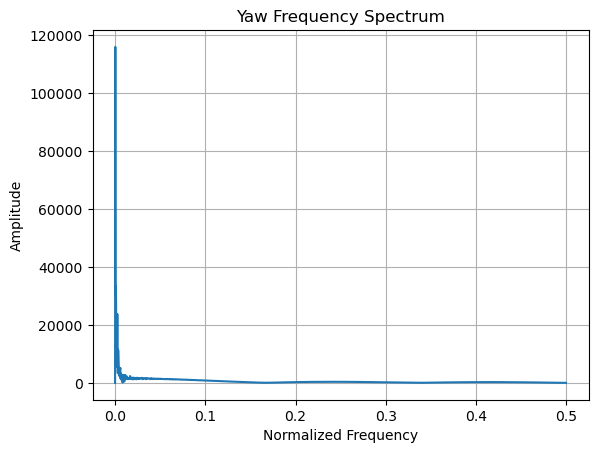

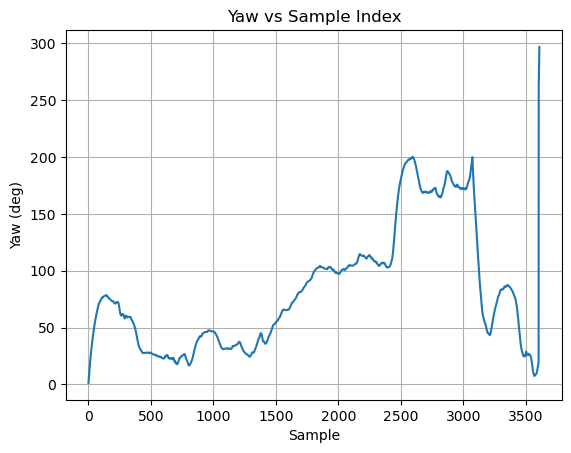


No catastrophic explosion detected (within ±360°)


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------- LOAD FILE ----------
with open("/Path_Name/raw_imu.txt", "r") as f:
    lines = f.readlines()

roll = []
pitch = []
yaw = []

# ---------- PARSE DATA ----------
pattern = r"Roll:\s*(-?\d+\.?\d*)\s*Pitch:\s*(-?\d+\.?\d*)\s*Yaw:\s*(-?\d+\.?\d*)"

for line in lines:
    match = re.search(pattern, line)
    if match:
        r = float(match.group(1))
        p = float(match.group(2))
        y = float(match.group(3))

        # Remove obvious corrupted values (> 360 degrees)
        if abs(r) < 360 and abs(p) < 360 and abs(y) < 360:
            roll.append(r)
            pitch.append(p)
            yaw.append(y)

roll = np.array(roll)
pitch = np.array(pitch)
yaw = np.array(yaw)

print("Total valid samples:", len(roll))

# ---------- BASIC STATISTICS ----------
def stats(name, data):
    print(f"\n{name} Statistics")
    print("Mean:", np.mean(data))
    print("Std Dev:", np.std(data))
    print("Min:", np.min(data))
    print("Max:", np.max(data))
    print("Peak-to-Peak:", np.ptp(data))

stats("Roll", roll)
stats("Pitch", pitch)
stats("Yaw", yaw)

# ---------- DRIFT ANALYSIS ----------
t = np.arange(len(yaw))
coeff = np.polyfit(t, yaw, 1)
drift_per_sample = coeff[0]

print("\nYaw Drift Slope (deg/sample):", drift_per_sample)

# ---------- FFT ANALYSIS ----------
yaw_detrended = yaw - np.mean(yaw)
fft_vals = np.fft.fft(yaw_detrended)
freq = np.fft.fftfreq(len(yaw_detrended))

plt.figure()
plt.plot(freq[:len(freq)//2], np.abs(fft_vals[:len(freq)//2]))
plt.title("Yaw Frequency Spectrum")
plt.xlabel("Normalized Frequency")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# ---------- STABILITY PLOT ----------
plt.figure()
plt.plot(yaw)
plt.title("Yaw vs Sample Index")
plt.xlabel("Sample")
plt.ylabel("Yaw (deg)")
plt.grid()
plt.show()

# ---------- EXPLOSION CHECK ----------
if np.any(np.abs(yaw) > 360):
    print("\nWARNING: Angle explosion detected (>360 deg)")
else:
    print("\nNo catastrophic explosion detected (within ±360°)")

Total gyro samples: 10703

GYRO BIAS (deg/s or raw units):
gx_bias = -0.10695256002989816
gy_bias = 0.06276361487433428
gz_bias = 0.0029024508081846212

GYRO NOISE STD:
gx_std = 0.0007958321922251525
gy_std = 0.0010091901953861867
gz_std = 0.0005301373021916542

MAG FIELD STABILITY:
Mean |B| = 1343.2741694437939
Std  |B| = 7.078625458746092

Suggested Madgwick beta: 1.1765308779861228e-05


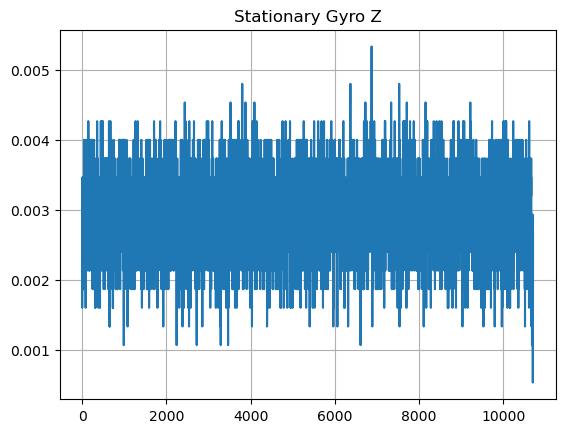

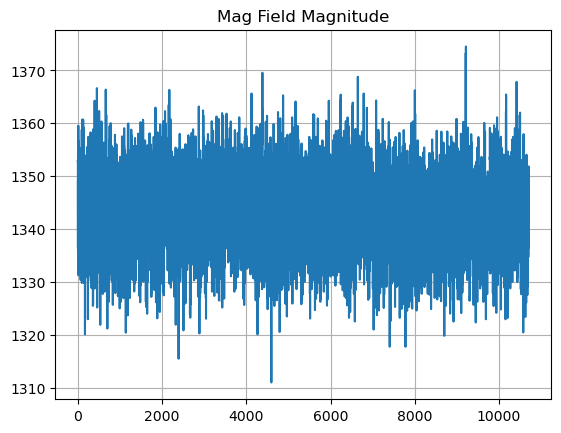

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

# --------- PARSE STATIONARY DATA ----------
with open("/Path_Name/stationary_raw.txt", "r") as f:
    lines = f.readlines()

# Modify these patterns if your stationary log contains raw gx gy gz mx my mz
gyro_pattern = r"gx:\s*(-?\d+\.?\d*)\s*gy:\s*(-?\d+\.?\d*)\s*gz:\s*(-?\d+\.?\d*)"
mag_pattern  = r"mx:\s*(-?\d+\.?\d*)\s*my:\s*(-?\d+\.?\d*)\s*mz:\s*(-?\d+\.?\d*)"

gx, gy, gz = [], [], []
mx, my, mz = [], [], []

for line in lines:
    g = re.search(gyro_pattern, line)
    m = re.search(mag_pattern, line)

    if g:
        gx.append(float(g.group(1)))
        gy.append(float(g.group(2)))
        gz.append(float(g.group(3)))

    if m:
        mx.append(float(m.group(1)))
        my.append(float(m.group(2)))
        mz.append(float(m.group(3)))

gx = np.array(gx)
gy = np.array(gy)
gz = np.array(gz)

mx = np.array(mx)
my = np.array(my)
mz = np.array(mz)

print("Total gyro samples:", len(gx))

# --------- GYRO BIAS ----------
gx_bias = np.mean(gx)
gy_bias = np.mean(gy)
gz_bias = np.mean(gz)

print("\nGYRO BIAS (deg/s or raw units):")
print("gx_bias =", gx_bias)
print("gy_bias =", gy_bias)
print("gz_bias =", gz_bias)

# --------- GYRO NOISE ----------
print("\nGYRO NOISE STD:")
print("gx_std =", np.std(gx))
print("gy_std =", np.std(gy))
print("gz_std =", np.std(gz))

# --------- MAGNITUDE STABILITY ----------
mag_norm = np.sqrt(mx**2 + my**2 + mz**2)

print("\nMAG FIELD STABILITY:")
print("Mean |B| =", np.mean(mag_norm))
print("Std  |B| =", np.std(mag_norm))

# --------- ESTIMATE MADGWICK BETA ----------
gyro_noise = np.mean([np.std(gx), np.std(gy), np.std(gz)])

# Convert deg/s noise to rad/s if necessary
gyro_noise_rad = gyro_noise * np.pi / 180.0

beta_estimate = np.sqrt(3/4) * gyro_noise_rad

print("\nSuggested Madgwick beta:", beta_estimate)

# --------- PLOTS ----------
plt.figure()
plt.plot(gz)
plt.title("Stationary Gyro Z")
plt.grid()
plt.show()

plt.figure()
plt.plot(mag_norm)
plt.title("Mag Field Magnitude")
plt.grid()
plt.show()

Total samples: 27413
Mean norm: 0.9999978637704081
Std norm: 2.175378216013944e-06
Roll std (deg): 0.08062019165105985
Pitch std (deg): 0.10913087806654388
Yaw std (deg): 0.042569415625912335


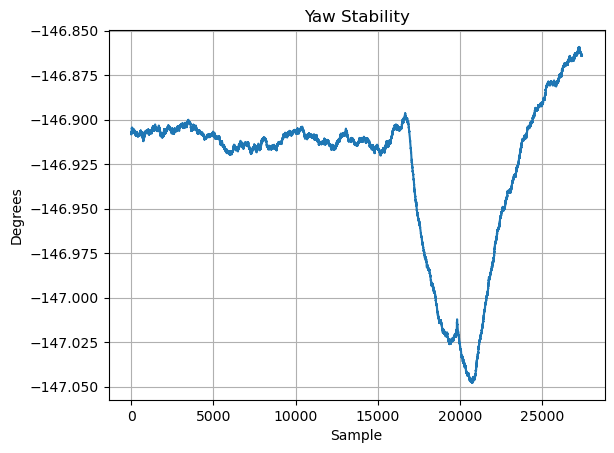

In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt

# -------- Parse quaternion file --------
q0, q1, q2, q3 = [], [], [], []

pattern = r"Q:\s*(-?\d+\.\d+)\s*(-?\d+\.\d+)\s*(-?\d+\.\d+)\s*(-?\d+\.\d+)"

with open("/Path_Name/quaternion_data.txt", "r") as f:
    for line in f:
        m = re.search(pattern, line)
        if m:
            q0.append(float(m.group(1)))
            q1.append(float(m.group(2)))
            q2.append(float(m.group(3)))
            q3.append(float(m.group(4)))

q0 = np.array(q0)
q1 = np.array(q1)
q2 = np.array(q2)
q3 = np.array(q3)

print("Total samples:", len(q0))

# -------- Norm check --------
norm = np.sqrt(q0**2 + q1**2 + q2**2 + q3**2)

print("Mean norm:", np.mean(norm))
print("Std norm:", np.std(norm))

# -------- Convert to Euler --------
roll  = np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1*q1 + q2*q2))
pitch = np.arcsin(2*(q0*q2 - q3*q1))
yaw   = np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3))

roll  = np.degrees(roll)
pitch = np.degrees(pitch)
yaw   = np.degrees(yaw)

print("Roll std (deg):", np.std(roll))
print("Pitch std (deg):", np.std(pitch))
print("Yaw std (deg):", np.std(yaw))

# -------- Plot yaw --------
plt.plot(yaw)
plt.title("Yaw Stability")
plt.xlabel("Sample")
plt.ylabel("Degrees")
plt.grid()
plt.show()

Total RPY samples: 9448
Total Quaternion samples: 18896

Quaternion Norm
Mean: 0.9999978621923545
Std : 2.1610177959393413e-06

Raw Euler STD (deg)
Roll : 0.23365893361305784
Pitch: 0.4434038881207618
Yaw  : 0.29035659550290965

Quaternion-derived Euler STD (deg)
Roll : 0.23349872179892422
Pitch: 0.4436387682377651
Yaw  : 0.2905046805444348

Euler vs Quaternion Difference STD (deg)
Roll : 0.2102213509591894
Pitch: 0.45387549118243237
Yaw  : 0.3453685697324651

Yaw Drift (deg/sample): -2.6793368730133292e-05


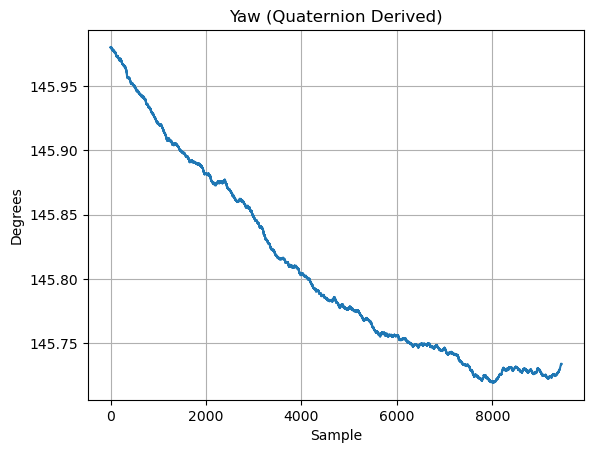

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt

# -------- Storage --------
roll_raw = []
pitch_raw = []
yaw_raw = []

q0_list = []
q1_list = []
q2_list = []
q3_list = []

# -------- Regex patterns --------
rpy_pattern = r"R:\s*(-?\d+\.?\d*)\s*P:\s*(-?\d+\.?\d*)\s*Y:\s*(-?\d+\.?\d*)"
quat_pattern = r"Q:\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)"

with open("/Path_Name/quat_roll_yaw_pitch.txt", "r") as f:
    for line in f:
        rpy = re.search(rpy_pattern, line)
        quat = re.search(quat_pattern, line)

        if rpy:
            roll_raw.append(float(rpy.group(1)))
            pitch_raw.append(float(rpy.group(2)))
            yaw_raw.append(float(rpy.group(3)))

        if quat:
            q0_list.append(float(quat.group(1)))
            q1_list.append(float(quat.group(2)))
            q2_list.append(float(quat.group(3)))
            q3_list.append(float(quat.group(4)))

roll_raw = np.array(roll_raw)
pitch_raw = np.array(pitch_raw)
yaw_raw = np.array(yaw_raw)

q0 = np.array(q0_list)
q1 = np.array(q1_list)
q2 = np.array(q2_list)
q3 = np.array(q3_list)

print("Total RPY samples:", len(roll_raw))
print("Total Quaternion samples:", len(q0))

# -------- Quaternion Norm Check --------
norm = np.sqrt(q0**2 + q1**2 + q2**2 + q3**2)

print("\nQuaternion Norm")
print("Mean:", np.mean(norm))
print("Std :", np.std(norm))

# -------- Convert Quaternion to Euler --------
roll_q  = np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1*q1 + q2*q2))
pitch_q = np.arcsin(2*(q0*q2 - q3*q1))
yaw_q   = np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3))

roll_q  = np.degrees(roll_q)
pitch_q = np.degrees(pitch_q)
yaw_q   = np.degrees(yaw_q)

# -------- Wrap yaw to 0–360 --------
yaw_q = (yaw_q + 360) % 360

# -------- Noise Stats --------
print("\nRaw Euler STD (deg)")
print("Roll :", np.std(roll_raw))
print("Pitch:", np.std(pitch_raw))
print("Yaw  :", np.std(yaw_raw))

print("\nQuaternion-derived Euler STD (deg)")
print("Roll :", np.std(roll_q))
print("Pitch:", np.std(pitch_q))
print("Yaw  :", np.std(yaw_q))

# -------- Consistency Check --------
min_len = min(len(roll_raw), len(roll_q))

roll_diff  = roll_raw[:min_len]  - roll_q[:min_len]
pitch_diff = pitch_raw[:min_len] - pitch_q[:min_len]
yaw_diff   = yaw_raw[:min_len]   - yaw_q[:min_len]

print("\nEuler vs Quaternion Difference STD (deg)")
print("Roll :", np.std(roll_diff))
print("Pitch:", np.std(pitch_diff))
print("Yaw  :", np.std(yaw_diff))

# -------- Drift Estimation --------
t = np.arange(min_len)
yaw_slope = np.polyfit(t, yaw_q[:min_len], 1)[0]

print("\nYaw Drift (deg/sample):", yaw_slope)

# -------- Plot Yaw --------
plt.figure()
plt.plot(yaw_q[:min_len])
plt.title("Yaw (Quaternion Derived)")
plt.xlabel("Sample")
plt.ylabel("Degrees")
plt.grid()
plt.show()

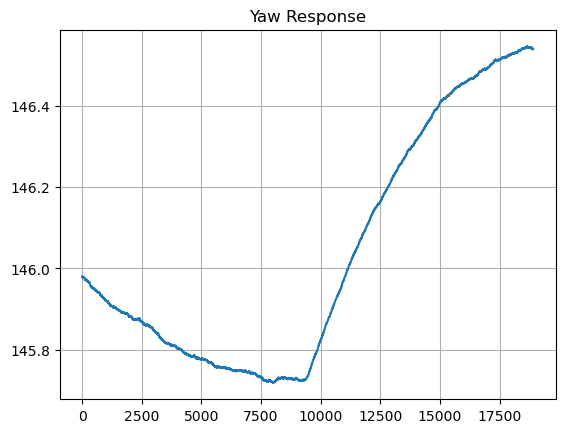

Yaw range: 0.8273225639732971
Yaw std after settle: 0.01588696317713603


In [5]:
import numpy as np
import re
import matplotlib.pyplot as plt

# Parse quaternion
q0,q1,q2,q3 = [],[],[],[]

pattern = r"Q:\s*(-?\d+\.\d+)\s*(-?\d+\.\d+)\s*(-?\d+\.\d+)\s*(-?\d+\.\d+)"

with open("/Path_Name/quat_roll_yaw_pitch.txt") as f:
    for line in f:
        m = re.search(pattern,line)
        if m:
            q0.append(float(m.group(1)))
            q1.append(float(m.group(2)))
            q2.append(float(m.group(3)))
            q3.append(float(m.group(4)))

q0 = np.array(q0)
q1 = np.array(q1)
q2 = np.array(q2)
q3 = np.array(q3)

# Convert to yaw
yaw = np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3))
yaw = np.degrees(yaw)

plt.plot(yaw)
plt.title("Yaw Response")
plt.grid()
plt.show()

print("Yaw range:", yaw.max()-yaw.min())
print("Yaw std after settle:", np.std(yaw[-2000:]))

In [6]:
print("Roll range:", roll_q.max() - roll_q.min())
print("Pitch range:", pitch_q.max() - pitch_q.min())
print("Yaw range:", yaw_q.max() - yaw_q.min())

Roll range: 0.5660005194926052
Pitch range: 1.0952742778457196
Yaw range: 0.8273225639732686


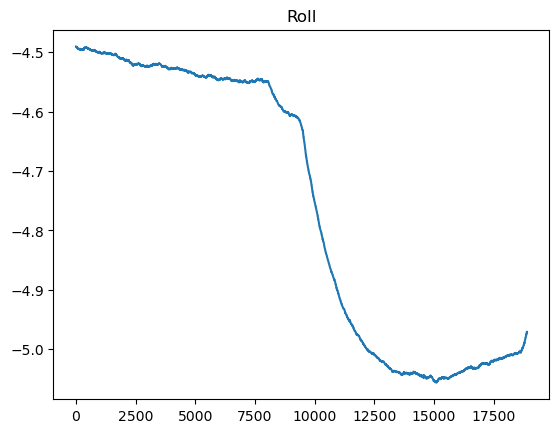

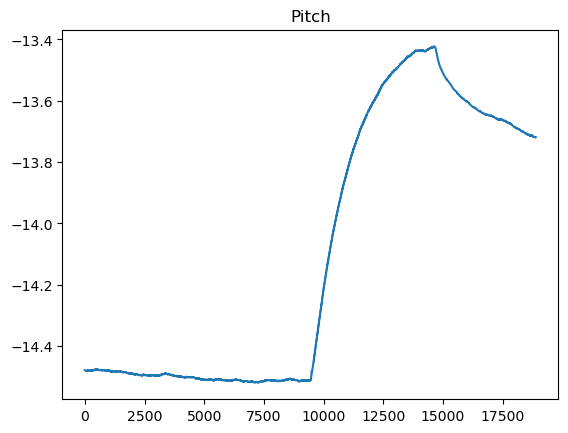

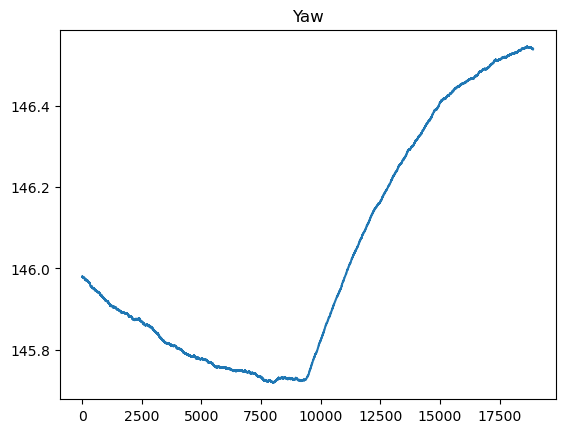

In [7]:
plt.plot(roll_q)
plt.title("Roll")
plt.show()

plt.plot(pitch_q)
plt.title("Pitch")
plt.show()

plt.plot(yaw_q)
plt.title("Yaw")
plt.show()

In [8]:
yaw_unwrapped = np.unwrap(np.radians(yaw_q))
yaw_unwrapped = np.degrees(yaw_unwrapped)

print("Unwrapped yaw range:", yaw_unwrapped.max() - yaw_unwrapped.min())

Unwrapped yaw range: 0.8273225639732686


In [9]:
import numpy as np

# Unwrap all Euler angles
roll_unwrapped  = np.degrees(np.unwrap(np.radians(roll_q)))
pitch_unwrapped = np.degrees(np.unwrap(np.radians(pitch_q)))
yaw_unwrapped   = np.degrees(np.unwrap(np.radians(yaw_q)))

print("Roll range (unwrapped):", roll_unwrapped.max() - roll_unwrapped.min())
print("Pitch range (unwrapped):", pitch_unwrapped.max() - pitch_unwrapped.min())
print("Yaw range (unwrapped):", yaw_unwrapped.max() - yaw_unwrapped.min())

Roll range (unwrapped): 0.5660005194926052
Pitch range (unwrapped): 1.0952742778457196
Yaw range (unwrapped): 0.8273225639732686


In [10]:
import numpy as np

# first and last quaternion
q_start = np.array([q0[0], q1[0], q2[0], q3[0]])
q_end   = np.array([q0[-1], q1[-1], q2[-1], q3[-1]])

# normalize (just to be safe)
q_start /= np.linalg.norm(q_start)
q_end   /= np.linalg.norm(q_end)

dot = np.abs(np.dot(q_start, q_end))
dot = np.clip(dot, -1.0, 1.0)

angle_deg = 2 * np.degrees(np.arccos(dot))

print("Total quaternion rotation (deg):", angle_deg)

Total quaternion rotation (deg): 0.9952682676567061


Total quaternion samples: 16505
Total RPY samples: 8253

Quaternion Norm
Mean: 1.0002404146888852
Std : 0.031159471641299532

Unwrapped Range
Roll : 51.53576436288173
Pitch: 76.71201734836067
Yaw  : 175.5786742817028

Total rotation (deg): 176.7969106399427

Settled STD (last 1000 samples)
Roll : 1.4300568078885296
Pitch: 1.9040916606616198
Yaw  : 2.301124420837054


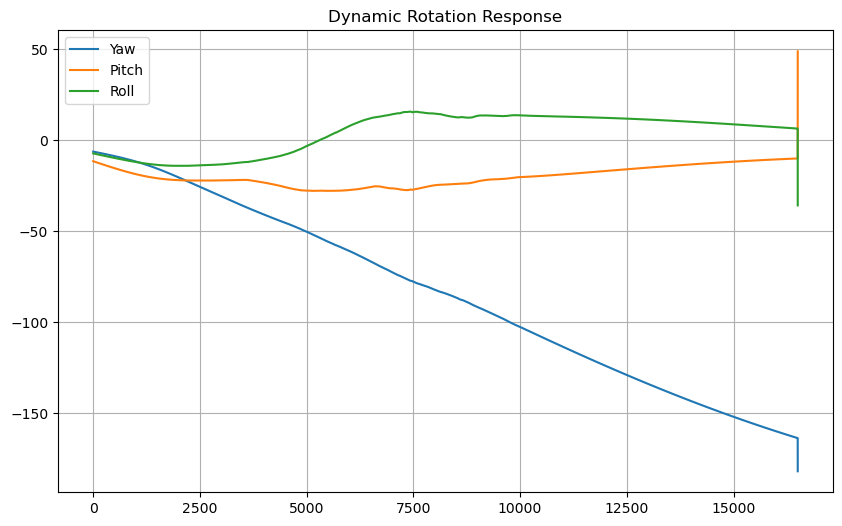

In [11]:
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------- STORAGE ----------
timestamps = []
roll_raw = []
pitch_raw = []
yaw_raw = []

q0_list = []
q1_list = []
q2_list = []
q3_list = []

# ---------- REGEX ----------
rpy_pattern = r"R:\s*(-?\d+\.?\d*)\s*P:\s*(-?\d+\.?\d*)\s*Y:\s*(-?\d+\.?\d*)"
quat_pattern_with_time = r"(\d+)\s+Q:\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)"
quat_pattern_no_time = r"Q:\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)"

with open("/Path_Name/quat_RPY_rotation.txt", "r") as f:
    for line in f:
        # RPY
        rpy = re.search(rpy_pattern, line)
        if rpy:
            roll_raw.append(float(rpy.group(1)))
            pitch_raw.append(float(rpy.group(2)))
            yaw_raw.append(float(rpy.group(3)))

        # Quaternion with timestamp
        quat_t = re.search(quat_pattern_with_time, line)
        if quat_t:
            timestamps.append(int(quat_t.group(1)))
            q0_list.append(float(quat_t.group(2)))
            q1_list.append(float(quat_t.group(3)))
            q2_list.append(float(quat_t.group(4)))
            q3_list.append(float(quat_t.group(5)))
            continue

        # Quaternion without timestamp
        quat = re.search(quat_pattern_no_time, line)
        if quat:
            q0_list.append(float(quat.group(1)))
            q1_list.append(float(quat.group(2)))
            q2_list.append(float(quat.group(3)))
            q3_list.append(float(quat.group(4)))

# Convert to numpy
q0 = np.array(q0_list)
q1 = np.array(q1_list)
q2 = np.array(q2_list)
q3 = np.array(q3_list)

roll_raw = np.array(roll_raw)
pitch_raw = np.array(pitch_raw)
yaw_raw = np.array(yaw_raw)

print("Total quaternion samples:", len(q0))
print("Total RPY samples:", len(roll_raw))

# ---------- QUATERNION NORM ----------
norm = np.sqrt(q0**2 + q1**2 + q2**2 + q3**2)
print("\nQuaternion Norm")
print("Mean:", np.mean(norm))
print("Std :", np.std(norm))

# ---------- CONVERT TO EULER ----------
roll_q  = np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1*q1 + q2*q2))
pitch_q = np.arcsin(2*(q0*q2 - q3*q1))
yaw_q   = np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3))

roll_q  = np.degrees(roll_q)
pitch_q = np.degrees(pitch_q)
yaw_q   = np.degrees(yaw_q)

# ---------- UNWRAP ----------
roll_unwrapped  = np.degrees(np.unwrap(np.radians(roll_q)))
pitch_unwrapped = np.degrees(np.unwrap(np.radians(pitch_q)))
yaw_unwrapped   = np.degrees(np.unwrap(np.radians(yaw_q)))

print("\nUnwrapped Range")
print("Roll :", roll_unwrapped.max() - roll_unwrapped.min())
print("Pitch:", pitch_unwrapped.max() - pitch_unwrapped.min())
print("Yaw  :", yaw_unwrapped.max() - yaw_unwrapped.min())

# ---------- TOTAL ROTATION FROM QUATERNION ----------
q_start = np.array([q0[0], q1[0], q2[0], q3[0]])
q_end   = np.array([q0[-1], q1[-1], q2[-1], q3[-1]])

q_start /= np.linalg.norm(q_start)
q_end   /= np.linalg.norm(q_end)

dot = np.abs(np.dot(q_start, q_end))
dot = np.clip(dot, -1.0, 1.0)

angle_deg = 2 * np.degrees(np.arccos(dot))
print("\nTotal rotation (deg):", angle_deg)

# ---------- SETTLED NOISE (last 1000 samples) ----------
N = 1000
print("\nSettled STD (last 1000 samples)")
print("Roll :", np.std(roll_unwrapped[-N:]))
print("Pitch:", np.std(pitch_unwrapped[-N:]))
print("Yaw  :", np.std(yaw_unwrapped[-N:]))

# ---------- PLOT ----------
plt.figure(figsize=(10,6))
plt.plot(yaw_unwrapped, label="Yaw")
plt.plot(pitch_unwrapped, label="Pitch")
plt.plot(roll_unwrapped, label="Roll")
plt.legend()
plt.grid()
plt.title("Dynamic Rotation Response")
plt.show()

Total quaternion samples: 8253
Total RPY samples: 0

Quaternion Norm
Mean: 1.0004807866058616
Std : 0.04406350119909023

Unwrapped Range
Roll : 51.535684143635564
Pitch: 76.7117372033319
Yaw  : 175.5786742817028

Total rotation (deg): 176.7969106399427

Settled STD (last 1000 samples)
Roll : 1.6383842012202041
Pitch: 2.029678061835035
Yaw  : 4.670418102397247

Min norm: 0.9999949464002306
Max norm: 5.003232130547013
Number of large deviations: 1
Example bad norms: [5.00323213]


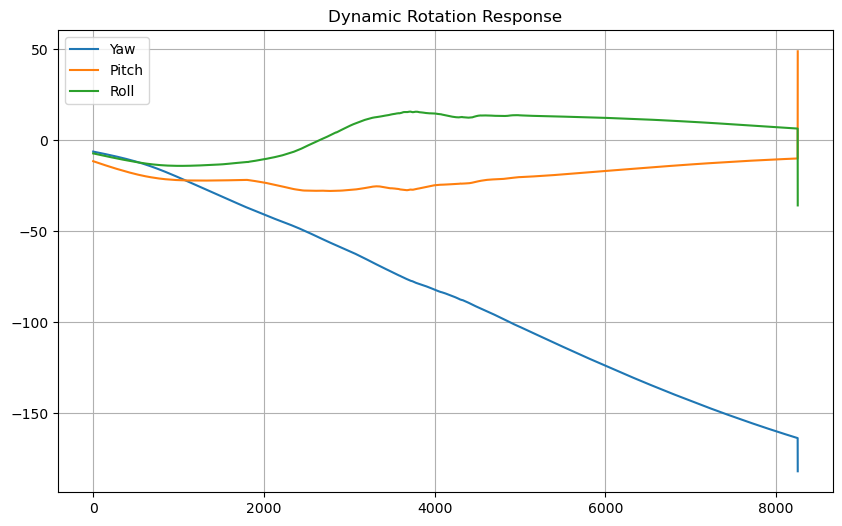

In [12]:
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------- STORAGE ----------
timestamps = []
roll_raw = []
pitch_raw = []
yaw_raw = []

q0_list = []
q1_list = []
q2_list = []
q3_list = []

# ---------- REGEX ----------
rpy_pattern = r"R:\s*(-?\d+\.?\d*)\s*P:\s*(-?\d+\.?\d*)\s*Y:\s*(-?\d+\.?\d*)"
quat_pattern_with_time = r"(\d+)\s+Q:\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)"
quat_pattern_with_time = r"(\d+)\s+Q:\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)\s*(-?\d+\.?\d*)"

with open("/Path_Name/quat_RPY_rotation.txt", "r") as f:
    for line in f:
        quat_t = re.search(quat_pattern_with_time, line)
        if quat_t:
            timestamps.append(int(quat_t.group(1)))
            q0_list.append(float(quat_t.group(2)))
            q1_list.append(float(quat_t.group(3)))
            q2_list.append(float(quat_t.group(4)))
            q3_list.append(float(quat_t.group(5)))

# Convert to numpy
q0 = np.array(q0_list)
q1 = np.array(q1_list)
q2 = np.array(q2_list)
q3 = np.array(q3_list)

roll_raw = np.array(roll_raw)
pitch_raw = np.array(pitch_raw)
yaw_raw = np.array(yaw_raw)

print("Total quaternion samples:", len(q0))
print("Total RPY samples:", len(roll_raw))

# ---------- QUATERNION NORM ----------
norm = np.sqrt(q0**2 + q1**2 + q2**2 + q3**2)
print("\nQuaternion Norm")
print("Mean:", np.mean(norm))
print("Std :", np.std(norm))

# ---------- CONVERT TO EULER ----------
roll_q  = np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1*q1 + q2*q2))
pitch_q = np.arcsin(2*(q0*q2 - q3*q1))
yaw_q   = np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3))

roll_q  = np.degrees(roll_q)
pitch_q = np.degrees(pitch_q)
yaw_q   = np.degrees(yaw_q)

# ---------- UNWRAP ----------
roll_unwrapped  = np.degrees(np.unwrap(np.radians(roll_q)))
pitch_unwrapped = np.degrees(np.unwrap(np.radians(pitch_q)))
yaw_unwrapped   = np.degrees(np.unwrap(np.radians(yaw_q)))

print("\nUnwrapped Range")
print("Roll :", roll_unwrapped.max() - roll_unwrapped.min())
print("Pitch:", pitch_unwrapped.max() - pitch_unwrapped.min())
print("Yaw  :", yaw_unwrapped.max() - yaw_unwrapped.min())

# ---------- TOTAL ROTATION FROM QUATERNION ----------
q_start = np.array([q0[0], q1[0], q2[0], q3[0]])
q_end   = np.array([q0[-1], q1[-1], q2[-1], q3[-1]])

q_start /= np.linalg.norm(q_start)
q_end   /= np.linalg.norm(q_end)

dot = np.abs(np.dot(q_start, q_end))
dot = np.clip(dot, -1.0, 1.0)

angle_deg = 2 * np.degrees(np.arccos(dot))
print("\nTotal rotation (deg):", angle_deg)

# ---------- SETTLED NOISE (last 1000 samples) ----------
N = 1000
print("\nSettled STD (last 1000 samples)")
print("Roll :", np.std(roll_unwrapped[-N:]))
print("Pitch:", np.std(pitch_unwrapped[-N:]))
print("Yaw  :", np.std(yaw_unwrapped[-N:]))

# Check min/max norm
print("\nMin norm:", norm.min())
print("Max norm:", norm.max())

# Find suspicious samples
bad_indices = np.where(np.abs(norm - 1) > 0.01)[0]
print("Number of large deviations:", len(bad_indices))

if len(bad_indices) > 0:
    print("Example bad norms:", norm[bad_indices[:10]])
    
# ---------- PLOT ----------
plt.figure(figsize=(10,6))
plt.plot(yaw_unwrapped, label="Yaw")
plt.plot(pitch_unwrapped, label="Pitch")
plt.plot(roll_unwrapped, label="Roll")
plt.legend()
plt.grid()
plt.title("Dynamic Rotation Response")
plt.show()
